In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
# Load the dataset
data = pd.read_csv("xy_data.csv")

# Assign t values uniformly between 6 and 60
N = len(data)
t = np.linspace(6, 60, N)

# Extract observed x, y
x_obs = data['x'].to_numpy()
y_obs = data['y'].to_numpy()


In [3]:
def parametric_curve(t, theta, M, X):
    """
    Compute (x, y) for given t, theta, M, X
    Parameters:
        t      : array of t values
        theta  : angle in radians
        M      : exponential coefficient
        X      : horizontal shift
    Returns:
        (x, y) : predicted coordinates
    """
    x = t * np.cos(theta) - np.exp(M * np.abs(t)) * np.sin(0.3 * t) * np.sin(theta) + X
    y = 42 + t * np.sin(theta) + np.exp(M * np.abs(t)) * np.sin(0.3 * t) * np.cos(theta)
    return x, y


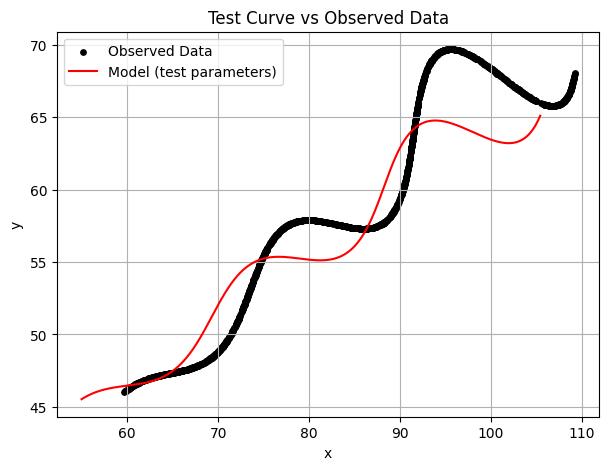

In [4]:
# Try a random set of parameters just to see what happens
theta_test = np.deg2rad(25)  # convert degrees to radians
M_test = 0.02
X_test = 50

x_pred, y_pred = parametric_curve(t, theta_test, M_test, X_test)

# Plot to visualize
plt.figure(figsize=(7,5))
plt.scatter(x_obs, y_obs, label='Observed Data', color='black', s=15)
plt.plot(x_pred, y_pred, color='red', label='Model (test parameters)')
plt.legend()
plt.title("Test Curve vs Observed Data")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()


In [5]:
from scipy.optimize import minimize


In [6]:
def loss(params):
    theta, M, X = params
    x_pred, y_pred = parametric_curve(t, theta, M, X)
    # L1 distance between predicted and observed points
    return np.sum(np.abs(x_pred - x_obs) + np.abs(y_pred - y_obs))


In [7]:
# Initial guesses (in radians for theta)
initial_guess = [np.deg2rad(25), 0.01, 50]

# Bounds for each parameter
bounds = [(np.deg2rad(0), np.deg2rad(50)), (-0.05, 0.05), (0, 100)]

# Run the optimizer
result = minimize(loss, initial_guess, bounds=bounds, method='L-BFGS-B')
theta_opt, M_opt, X_opt = result.x

print("Optimal θ (deg):", np.rad2deg(theta_opt))
print("Optimal M:", M_opt)
print("Optimal X:", X_opt)


Optimal θ (deg): 28.127500959191075
Optimal M: 0.021332974368470405
Optimal X: 54.9010645075369


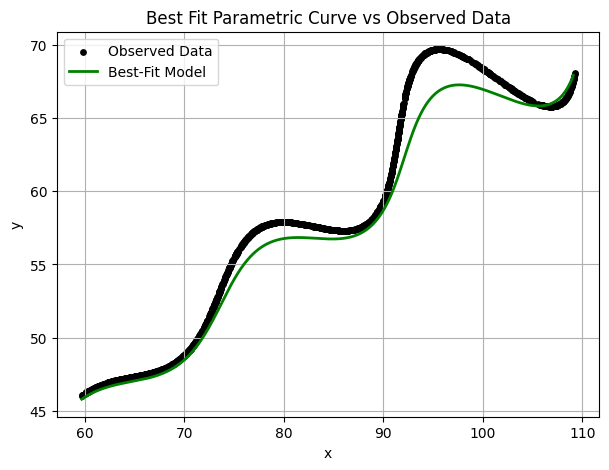

In [8]:
x_best, y_best = parametric_curve(t, theta_opt, M_opt, X_opt)

plt.figure(figsize=(7,5))
plt.scatter(x_obs, y_obs, color='black', s=15, label='Observed Data')
plt.plot(x_best, y_best, color='green', lw=2, label='Best-Fit Model')
plt.title("Best Fit Parametric Curve vs Observed Data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()
